# Isolation Forest — MPLS Network Anomaly Detection

**Goal**: Train an Isolation Forest to detect network anomalies from high-dimensional rolling-window telemetry features.

**Why IF?** Catches density-based outliers the AE models miss — congestion patterns and subtle multi-dimensional shifts.

**Feature space**: 23 numeric telemetry cols + 1 link_state + 46 rolling features (30s mean/slope) = **70 features**.

In [2]:
# Cell 0: Install dependencies (run once)
# sklearn is pre-installed on Kaggle — only optuna for HPO
!pip install -q optuna
print("Dependencies installed.")

Dependencies installed.


In [3]:
# Cell 1: Imports
import os, sys, json, gc, warnings, pickle, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)
import joblib
import optuna

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print(f"pandas {pd.__version__}, sklearn OK, optuna {optuna.__version__}")

pandas 2.3.3, sklearn OK, optuna 4.8.0


In [13]:
# Cell 2: Configuration

class Config:
    # --- Paths (update to match your Kaggle dataset) ---
    data_dir = '/kaggle/input/datasets/visheshaggarwal/mpls-network-telemetry'
    model_dir = '/kaggle/working'
    train_csv = os.path.join(data_dir, 'telemetry_train.csv')
    val_csv = os.path.join(data_dir, 'telemetry_val.csv')
    
    # --- Features ---
    numeric_cols = [
            'bytes_in',
            'bytes_out',
            'packets_in',
            'packets_out',
            'errors_in',
            'drops_in',
            'drops_out',
            'utilization_pct',
            'bgp_sessions_active',
            'bgp_prefixes_received',
            'bgp_updates_per_min',
            'bgp_withdrawals_per_min',
            'ospf_spf_runs',
            'ldp_sessions_active',
            'mpls_lsp_count',
            'mpls_label_table_size',
            'vpn_routes_count',
            'cpu_load_pct',
            'memory_used_pct',
            'queue_depth',
            'latency_ms',
            'jitter_ms',
            'packet_loss_pct',
        ]
    
    # --- IF Training ---
    n_trials = 15
    max_train_rows = 300000  # cap for HPO speed; full data for final training

cfg = Config()
print("Configuration loaded.")
print(f"Train: {cfg.train_csv}")
print(f"Val: {cfg.val_csv}")

Configuration loaded.
Train: /kaggle/input/datasets/visheshaggarwal/mpls-network-telemetry/telemetry_train.csv
Val: /kaggle/input/datasets/visheshaggarwal/mpls-network-telemetry/telemetry_val.csv


In [7]:
# Cell 3: Data Loading

print("Loading training data...")
train_df = pd.read_csv(cfg.train_csv, low_memory=False)
print(f"Train shape: {train_df.shape}, columns: {len(train_df.columns)}")

print("\nLoading validation data...")
val_df = pd.read_csv(cfg.val_csv, low_memory=False)
print(f"Val shape: {val_df.shape}, columns: {len(val_df.columns)}")

# Check anomaly rates
print(f"\nTrain anomaly rate: {train_df['is_anomaly'].mean():.3%}")
print(f"Val anomaly rate: {val_df['is_anomaly'].mean():.3%}")

# Check fault type distribution
print("\nTrain fault types:")
print(train_df['fault_type'].value_counts())
print("\nVal fault types:")
print(val_df['fault_type'].value_counts())

Loading training data...
Train shape: (1296000, 92), columns: 92

Loading validation data...
Val shape: (432000, 92), columns: 92

Train anomaly rate: 4.838%
Val anomaly rate: 5.903%

Train fault types:
fault_type
none            1233300
mpls_failure      32400
policy_drift      12600
bgp_flap           9600
congestion         8100
Name: count, dtype: int64

Val fault types:
fault_type
none            406500
mpls_failure     18000
bgp_flap          4800
congestion        2700
Name: count, dtype: int64


In [8]:
# Cell 4: Feature Engineering — Rolling Windows
# Build rolling mean/std/slope at 30s, 300s, 3600s per-node

ROLLING_WINDOWS_SEC = [30, 300, 3600]

def build_features(df):
    """Add rolling window features per node."""
    result_frames = []
    for node_id, grp in df.groupby('node_id'):
        grp = grp.sort_values('timestamp').copy()
        for col in cfg.numeric_cols:
            if col not in grp.columns:
                continue
            for w in ROLLING_WINDOWS_SEC:
                steps = max(1, w // 2)
                rolled = grp[col].rolling(window=steps, min_periods=1)
                grp[f'{col}_mean_{w}s'] = rolled.mean()
                grp[f'{col}_std_{w}s'] = rolled.std().fillna(0)
                grp[f'{col}_slope_{w}s'] = (
                    (grp[col] - grp[col].shift(steps)).fillna(0) / w
                )
        result_frames.append(grp)
    return pd.concat(result_frames).sort_index()

print("Building rolling features for training set...")
t0 = time.time()
train_df = build_features(train_df)
print(f"Done. Train shape: {train_df.shape}, time: {time.time()-t0:.1f}s")

print("\nBuilding rolling features for validation set...")
t0 = time.time()
val_df = build_features(val_df)
print(f"Done. Val shape: {val_df.shape}, time: {time.time()-t0:.1f}s")

# Quick check rolling columns exist
rolling_cols = [c for c in train_df.columns if '_mean_30s' in c]
print(f"\nRolling columns added: {len(rolling_cols)} per node")

Building rolling features for training set...
Done. Train shape: (1296000, 299), time: 18.9s

Building rolling features for validation set...
Done. Val shape: (432000, 299), time: 6.0s

Rolling columns added: 23 per node


In [9]:
# Cell 5: IF Feature Matrix Builder

LINK_STATE_MAP = {'UP': 0, 'FLAPPING': 1, 'DOWN': 2, 'N/A': 0}

def get_if_features(df):
    """Build 70-dim IF feature matrix from DataFrame."""
    cols = [c for c in cfg.numeric_cols if c in df.columns]
    X = df[cols].values.astype(np.float32)
    
    # Encode link_state
    ls = df['link_state'].map(LINK_STATE_MAP).fillna(0).values.reshape(-1, 1).astype(np.float32)
    X = np.hstack([X, ls])
    
    # Append 30s rolling features
    temporal_cols = []
    for col in cfg.numeric_cols:
        for suffix in (f'{col}_mean_30s', f'{col}_slope_30s'):
            if suffix in df.columns:
                temporal_cols.append(suffix)
    if temporal_cols:
        T = df[temporal_cols].values.astype(np.float32)
        X = np.hstack([X, T])
    return X

# Build full feature matrices
X_train_raw = get_if_features(train_df)
y_train_raw = train_df['is_anomaly'].values.astype(np.int32)
fault_train = train_df['fault_type'].values

X_val = get_if_features(val_df)
y_val = val_df['is_anomaly'].values.astype(np.int32)
fault_val = val_df['fault_type'].values

print(f"X_train: {X_train_raw.shape}, y_train: {y_train_raw.mean():.3%} anomalous")
print(f"X_val:   {X_val.shape}, y_val: {y_val.mean():.3%} anomalous")

# Separate normal vs anomalous for training (fit scaler + IF on normal only)
normal_mask = y_train_raw == 0
X_train_normal = X_train_raw[normal_mask]

X_train: (1296000, 70), y_train: 4.838% anomalous
X_val:   (432000, 70), y_val: 5.903% anomalous


In [10]:
# Cell 6: Normalization
# Fit scaler on NORMAL training rows only → anomalous become outliers

scaler = StandardScaler()
scaler.fit(X_train_normal)
print(f"Scaler fitted on {len(X_train_normal):,} normal rows")

# Transform all data
X_train_norm = scaler.transform(X_train_raw)
X_train_normal_norm = scaler.transform(X_train_normal)
X_val_norm = scaler.transform(X_val)

print(f"Normalized: mean~{X_train_norm.mean():.4f}, std~{X_train_norm.std():.4f}")

# Save scaler
scaler_path = os.path.join(cfg.model_dir, 'if_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

Scaler fitted on 1,233,300 normal rows
Normalized: mean~2.1256, std~139.3907
Scaler saved to /kaggle/working/if_scaler.pkl


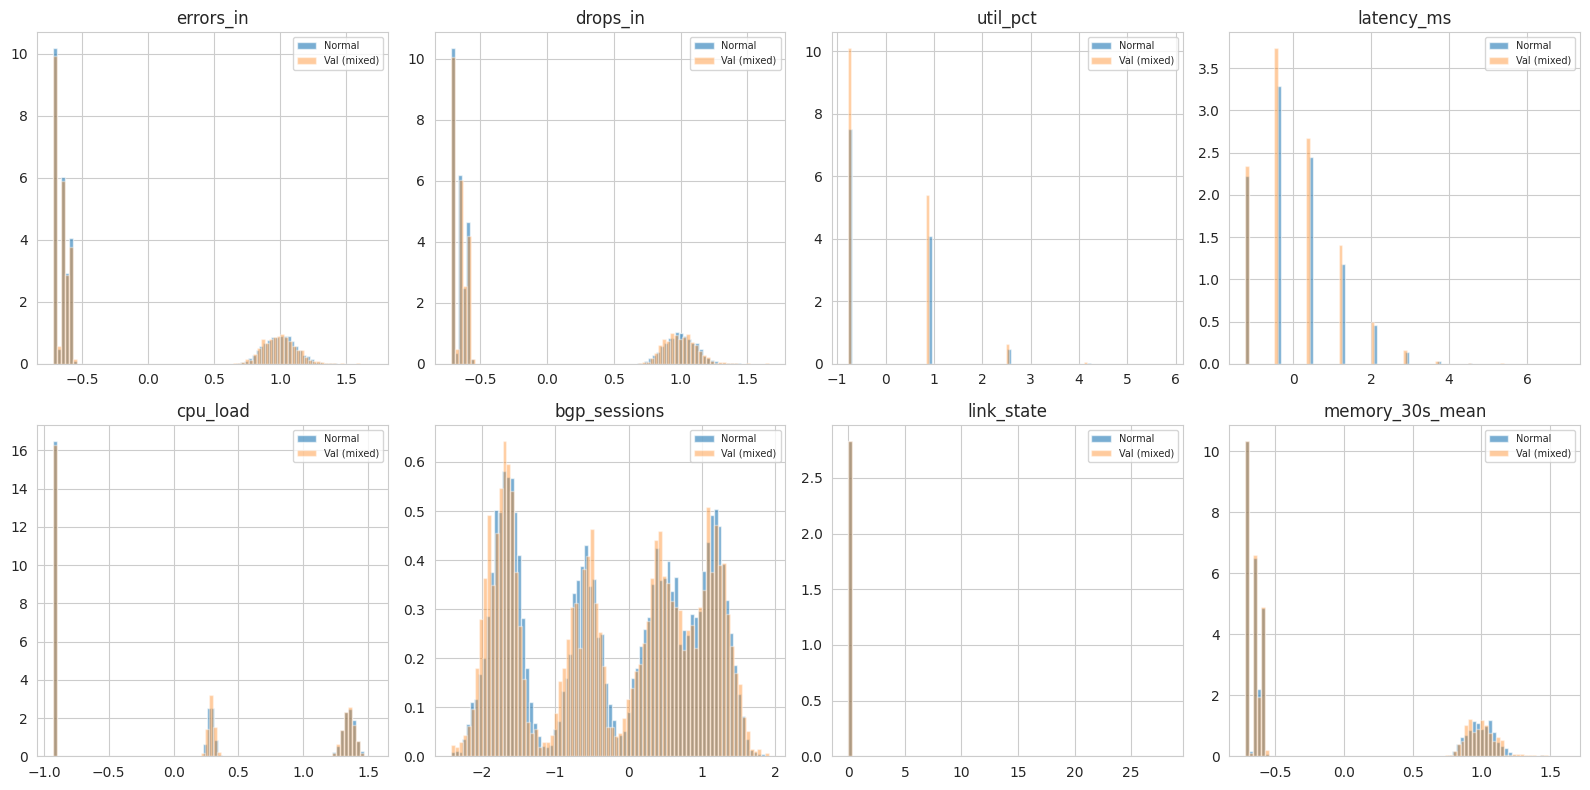

Feature matrix: 70 dimensions


In [11]:
# Cell 7: EDA — Quick feature distribution check

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Sample a few features
sample_features = [0, 1, 5, 10, 15, 20, 23, 30]
names = ['errors_in', 'drops_in', 'util_pct', 'latency_ms',
         'cpu_load', 'bgp_sessions', 'link_state', 'memory_30s_mean']

for i, (fi, name) in enumerate(zip(sample_features, names)):
    ax = axes[i // 4, i % 4]
    ax.hist(X_train_normal_norm[:10000, fi], bins=80, alpha=0.6, label='Normal', density=True)
    ax.hist(X_val_norm[:5000, fi], bins=80, alpha=0.4, label='Val (mixed)', density=True)
    ax.set_title(name)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print(f"Feature matrix: {X_train_norm.shape[1]} dimensions")

In [14]:
# Cell 8: Optuna Hyperparameter Tuning
# Use a subset for HPO speed; final training uses full data

tune_size = min(cfg.max_train_rows, len(X_train_normal_norm))
rng = np.random.RandomState(42)
tune_idx = rng.choice(len(X_train_normal_norm), tune_size, replace=False)
X_tune = X_train_normal_norm[tune_idx]
print(f"HPO training on {len(X_tune):,} normal rows")

# For HPO objective, we need anomalous data for AUROC — use val set
val_tune_size = min(30000, len(X_val_norm))
val_idx = rng.choice(len(X_val_norm), val_tune_size, replace=False)
X_val_tune = X_val_norm[val_idx]
y_val_tune = y_val[val_idx]
print(f"HPO validation on {len(X_val_tune):,} rows (anomaly rate: {y_val_tune.mean():.3%})")


def objective(trial):
    contamination = trial.suggest_float('contamination', 0.001, 0.2, log=True)
    n_estimators = trial.suggest_categorical('n_estimators', [100, 200, 300, 500])
    max_samples = trial.suggest_categorical('max_samples', ['auto', 0.3, 0.5, 0.8])
    max_features = trial.suggest_float('max_features', 0.3, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42,
        n_jobs=-1,
        warm_start=True,
    )
    
    # Fit on normal tuning subset
    model.fit(X_tune)
    # Score on val subset
    scores = -model.score_samples(X_val_tune)
    auroc = roc_auc_score(y_val_tune, scores)
    # Also track AP
    ap = average_precision_score(y_val_tune, scores)
    trial.set_user_attr('ap', ap)
    
    del model
    gc.collect()
    return auroc


print("Starting Optuna hyperparameter search...")
print(f"{cfg.n_trials} trials, optimizing AUROC")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
study.optimize(objective, n_trials=cfg.n_trials, show_progress_bar=True)

print(f"\nBest trial: {study.best_trial.number}")
print(f"Best AUROC: {study.best_value:.4f}")
print(f"Best AP: {study.best_trial.user_attrs['ap']:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-06-21 23:22:25,798] A new study created in memory with name: no-name-496a2219-63e7-4401-9a0a-11f89d4a0566


HPO training on 300,000 normal rows
HPO validation on 30,000 rows (anomaly rate: 5.933%)
Starting Optuna hyperparameter search...
15 trials, optimizing AUROC


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-21 23:23:01,899] Trial 0 finished with value: 0.858114792282149 and parameters: {'contamination': 0.00727491708802781, 'n_estimators': 100, 'max_samples': 0.5, 'max_features': 0.7956508044572318, 'bootstrap': False}. Best is trial 0 with value: 0.858114792282149.
[I 2026-06-21 23:24:56,650] Trial 1 finished with value: 0.8776317895508006 and parameters: {'contamination': 0.0823143373099555, 'n_estimators': 500, 'max_samples': 0.8, 'max_features': 0.3976457024564293, 'bootstrap': False}. Best is trial 1 with value: 0.8776317895508006.
[I 2026-06-21 23:25:35,919] Trial 2 finished with value: 0.837514532684605 and parameters: {'contamination': 0.01120548642504815, 'n_estimators': 100, 'max_samples': 0.3, 'max_features': 0.9642198760773333, 'bootstrap': True}. Best is trial 1 with value: 0.8776317895508006.
[I 2026-06-21 23:26:45,019] Trial 3 finished with value: 0.8705487183366645 and parameters: {'contamination': 0.0050225633119947675, 'n_estimators': 200, 'max_samples': 0.5, 

In [16]:
# Cell 9: Final Training with Best Hyperparameters

best_params = study.best_params
print(f"Training final IF with: {best_params}")
print(f"Training on {len(X_train_normal_norm):,} normal rows (full dataset)")

final_model = IsolationForest(
    n_estimators=best_params['n_estimators'],
    contamination=best_params['contamination'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    bootstrap=best_params['bootstrap'],
    random_state=42,
    n_jobs=-1,
    warm_start=True,
)

t0 = time.time()
final_model.fit(X_train_normal_norm)
print(f"Training time: {time.time()-t0:.1f}s")
print(f"n_estimators: {final_model.n_estimators}")
print(f"n_features: {final_model.n_features_in_}")

Training final IF with: {'contamination': 0.007840758945457348, 'n_estimators': 200, 'max_samples': 0.5, 'max_features': 0.9908208556203622, 'bootstrap': True}
Training on 1,233,300 normal rows (full dataset)
Training time: 414.0s
n_estimators: 200
n_features: 70


In [17]:
# Cell 10: Threshold Calibration

print("Scoring validation set...")
val_scores = -final_model.score_samples(X_val_norm)

# Separate normal vs anomalous
normal_mask = y_val == 0
anom_mask = y_val == 1
val_normal_scores = val_scores[normal_mask]
val_anom_scores = val_scores[anom_mask]

print(f"Normal scores:    {len(val_normal_scores):,}, mean={val_normal_scores.mean():.4f}")
print(f"Anomalous scores: {len(val_anom_scores):,}, mean={val_anom_scores.mean():.4f}")
print(f"Separation ratio: {val_anom_scores.mean() / max(val_normal_scores.mean(), 1e-12):.2f}x")

# Find best F1 threshold
all_errors = np.concatenate([val_normal_scores, val_anom_scores])
all_labels = np.concatenate([np.zeros_like(val_normal_scores), np.ones_like(val_anom_scores)])

precisions, recalls, thresholds = precision_recall_curve(all_labels, all_errors)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"\nBest threshold: {best_thresh:.6f} (F1={best_f1:.4f})")

# Also compute 95th percentile on normal
thresh_p95 = float(np.percentile(val_normal_scores, 95))
print(f"95th-pct threshold: {thresh_p95:.6f}")

# AUROC & AP
auroc = roc_auc_score(all_labels, all_errors)
ap = average_precision_score(all_labels, all_errors)
print(f"\nAUROC: {auroc:.4f}")
print(f"Avg Precision: {ap:.4f}")
print(f"F1: {best_f1:.4f} (at threshold {best_thresh:.6f})")

# Classification report at best threshold
preds = (all_errors >= best_thresh).astype(int)
print("\nClassification Report:")
print(classification_report(all_labels, preds, target_names=['Normal', 'Anomaly']))

Scoring validation set...
Normal scores:    406,500, mean=0.3925
Anomalous scores: 25,500, mean=0.5049
Separation ratio: 1.29x

Best threshold: 0.467157 (F1=0.7618)
95th-pct threshold: 0.425599

AUROC: 0.9000
Avg Precision: 0.7469
F1: 0.7618 (at threshold 0.467157)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99    406500
     Anomaly       0.96      0.63      0.76     25500

    accuracy                           0.98    432000
   macro avg       0.97      0.81      0.87    432000
weighted avg       0.98      0.98      0.97    432000



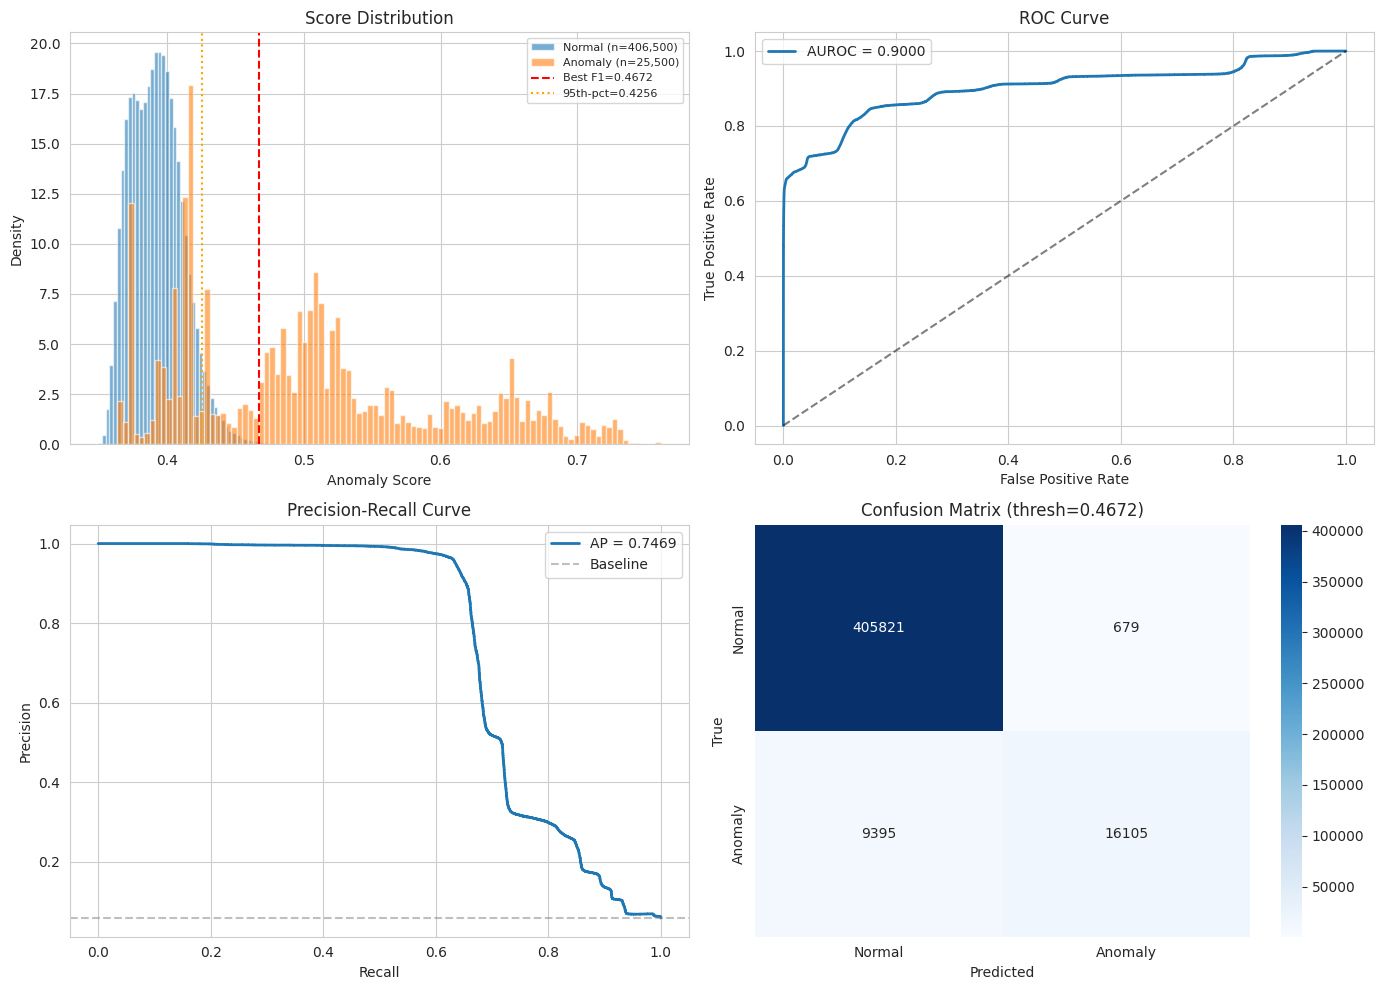

In [19]:
# Cell 11: Evaluation Plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 11a: Score distributions
ax = axes[0, 0]
ax.hist(val_normal_scores, bins=100, alpha=0.6, label=f'Normal (n={len(val_normal_scores):,})', density=True)
ax.hist(val_anom_scores, bins=100, alpha=0.6, label=f'Anomaly (n={len(val_anom_scores):,})', density=True)
ax.axvline(best_thresh, color='red', linestyle='--', label=f'Best F1={best_thresh:.4f}')
ax.axvline(thresh_p95, color='orange', linestyle=':', label=f'95th-pct={thresh_p95:.4f}')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution')
ax.legend(fontsize=8)

# 11b: ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(all_labels, all_errors)
ax.plot(fpr, tpr, lw=2, label=f'AUROC = {auroc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# 11c: PR Curve
ax = axes[1, 0]
ax.plot(recalls, precisions, lw=2, label=f'AP = {ap:.4f}')
ax.axhline(y=all_labels.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

# 11d: Confusion Matrix
ax = axes[1, 1]
cm = confusion_matrix(all_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (thresh={best_thresh:.4f})')

plt.tight_layout()
plt.show()

In [20]:
# Cell 12: Per-Fault-Type Analysis

print("Per-Fault-Type Detection Performance (val set):")
print("=" * 70)

fault_types = np.unique(fault_val)
results = []

for ft in fault_types:
    mask = fault_val == ft
    n = mask.sum()
    ft_scores = val_scores[mask]
    
    if ft == 'none':
        det_rate = (ft_scores > best_thresh).mean()
        print(f"  {ft:<20s}: n={n:6d}, mean_score={ft_scores.mean():.4f}, false_pos_rate={det_rate:.2%}")
    else:
        ft_labels = y_val[mask]
        ft_preds = (ft_scores > best_thresh).astype(int)
        tp = ((ft_labels == 1) & (ft_preds == 1)).sum()
        fn = ((ft_labels == 1) & (ft_preds == 0)).sum()
        recall = tp / max(tp + fn, 1)
        results.append({'fault': ft, 'n': n, 'mean_score': ft_scores.mean(),
                        'median_score': np.median(ft_scores), 'recall': recall})
        print(f"  {ft:<20s}: n={n:5d}, mean={ft_scores.mean():>10.4f}, median={np.median(ft_scores):>10.4f}, recall={recall:.2%}")

results_df = pd.DataFrame(results)
print(f"\nOverall: AUROC={auroc:.4f}, AP={ap:.4f}, F1={best_f1:.4f}")

Per-Fault-Type Detection Performance (val set):
  bgp_flap            : n= 4800, mean=    0.5725, median=    0.6179, recall=73.42%
  congestion          : n= 2700, mean=    0.5521, median=    0.5317, recall=81.81%
  mpls_failure        : n=18000, mean=    0.4798, median=    0.4820, recall=57.62%
  none                : n=406500, mean_score=0.3925, false_pos_rate=0.17%

Overall: AUROC=0.9000, AP=0.7469, F1=0.7618


In [21]:
# Cell 13: Save Final Model & Download

final_path = os.path.join(cfg.model_dir, 'isolation_forest.pkl')
joblib.dump({
    'model': final_model,
    'scaler': scaler,
    'threshold': best_thresh,
    'hparams': best_params,
    'val_auroc': auroc,
    'val_ap': ap,
    'val_f1': best_f1,
}, final_path)
print(f"Final model saved to {final_path}")
print(f"  n_features={final_model.n_features_in_}")
print(f"  threshold={best_thresh:.6f}")
print(f"  Val AUROC={auroc:.4f}, AP={ap:.4f}, F1={best_f1:.4f}")

# Verify
print("\nVerifying saved model...")
verify = joblib.load(final_path)
print(f"  model: {type(verify['model']).__name__}")
print(f"  hparams: {verify['hparams']}")
print(f"  Model loads correctly ✓")

# Create zip for download
import zipfile
from IPython.display import FileLink

zip_path = os.path.join(cfg.model_dir, 'isolation_forest_model.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(final_path, 'isolation_forest.pkl')
    zf.write(scaler_path, 'if_scaler.pkl')
print(f"\nZip created: {zip_path} ({os.path.getsize(zip_path) / 1024 / 1024:.1f} MB)")
display(FileLink(zip_path))

Final model saved to /kaggle/working/isolation_forest.pkl
  n_features=70
  threshold=0.467157
  Val AUROC=0.9000, AP=0.7469, F1=0.7618

Verifying saved model...
  model: IsolationForest
  hparams: {'contamination': 0.007840758945457348, 'n_estimators': 200, 'max_samples': 0.5, 'max_features': 0.9908208556203622, 'bootstrap': True}
  Model loads correctly ✓

Zip created: /kaggle/working/isolation_forest_model.zip (117.7 MB)


/kaggle/working/isolation_forest_model.zip

In [23]:
# Cell 14: Summary & Comparison

print("=" * 60)
print("ISOLATION FOREST — TRAINING SUMMARY")
print("=" * 60)
print(f"\nTraining data: {len(X_train_normal_norm):,} normal rows")
print(f"Features: {X_train_norm.shape[1]} dimensions")
print(f"Best params: {best_params}")
print(f"\nVal set performance:")
print(f"  AUROC: {auroc:.4f}")
print(f"  AP:    {ap:.4f}")
print(f"  F1:    {best_f1:.4f} (thresh={best_thresh:.6f})")
print(f"\nModel saved to: {final_path}")
print(f"Scaler saved to: {scaler_path}")
print("=" * 60)
print("\nComparison with existing IF (trained locally):")
print("  Existing: 300 trees, fixed batch 50, contamination='auto', 200K cap")
print(f"  New:      {best_params['n_estimators']} trees, contamination={best_params['contamination']:.4f}, full data")
print("\nNext: integrate with ensemble + copilot")

ISOLATION FOREST — TRAINING SUMMARY

Training data: 1,233,300 normal rows
Features: 70 dimensions
Best params: {'contamination': 0.007840758945457348, 'n_estimators': 200, 'max_samples': 0.5, 'max_features': 0.9908208556203622, 'bootstrap': True}

Val set performance:
  AUROC: 0.9000
  AP:    0.7469
  F1:    0.7618 (thresh=0.467157)

Model saved to: /kaggle/working/isolation_forest.pkl
Scaler saved to: /kaggle/working/if_scaler.pkl

Comparison with existing IF (trained locally):
  Existing: 300 trees, fixed batch 50, contamination='auto', 200K cap
  New:      200 trees, contamination=0.0078, full data

Next: integrate with ensemble + copilot
